# Two-Phase Fine-Tuning × 5 Seeds → mean ± SD
**WasteLens / EcoVision AI thesis — 4-model comparison (MobileNetV3-Large, ResNet50, DenseNet121, EfficientNet-B0)**

One **identical** protocol for every architecture (this removes the recipe differences between the earlier per-model notebooks):

| | Phase 1 — head only | Phase 2 — partial fine-tune |
|---|---|---|
| Trainable | classification head, backbone frozen (BN of frozen part kept in eval mode) | head + last block(s) of the backbone |
| Epochs | 8 (best val-loss weights kept) | up to 30, **early stopping on validation loss** (patience 7) |
| LR | 1e-3 (AdamW) | backbone 2e-5, head 1e-4 (AdamW) + ReduceLROnPlateau on val loss |
| Loss | class-weighted CE (same for all models) | same |

Then **5 independent seeds** per model → report **mean ± SD** (and 95 % t-CI) on the leakage-free **N = 624** test set.

**Before running**
1. Session options: **GPU on**, **Internet on** (first run downloads ImageNet weights).
2. Inputs attached: `full-final-dataset-code` (images + `research_metadata`) and `Final_Waste_4_Model_Comparative_Research` (needed for the N = 624 sample list).
3. Every finished run is saved to `runs/`. If the session dies, just **Run All** again — completed runs are skipped.

In [1]:
# ============================================================
# 01 — IMPORTS + EXPERIMENT CONFIG
# ============================================================
import os, gc, json, time, math, copy, random, shutil, warnings, traceback
from pathlib import Path
from itertools import combinations
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torchvision
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from scipy import stats
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- experiment design ----------------
MODELS     = ["mobilenet_v3_large", "resnet50", "densenet121", "efficientnet_b0"]
RUN_MODELS = MODELS                       # e.g. ["resnet50", "densenet121"] to split work across sessions
SEEDS      = [42, 123, 2024, 3407, 777]   # 5 independent seeds

CLASS_NAMES  = ["Cardboard", "Glass", "Metal", "Paper", "Plastic"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 4
WEIGHT_DECAY = 1e-4

# Phase 1 (head only)
P1_EPOCHS = 8
P1_LR     = 1e-3

# Phase 2 (unfreeze last blocks)
P2_MAX_EPOCHS   = 30
P2_BACKBONE_LR  = 2e-5
P2_HEAD_LR      = 1e-4
P2_PATIENCE     = 7        # early stopping on validation loss
SCHED_PATIENCE  = 2        # ReduceLROnPlateau on validation loss

USE_CLASS_WEIGHTS = True   # identical loss for all four models
USE_AMP   = True           # mixed precision (GPU only)
ECE_BINS  = 15
AMP_ON    = USE_AMP and DEVICE.type == "cuda"

# Which parameters are "head" and which extra blocks Phase 2 unfreezes
HEAD_PREFIX = {
    "resnet50":           ["fc"],
    "densenet121":        ["classifier"],
    "efficientnet_b0":    ["classifier"],
    "mobilenet_v3_large": ["classifier"],
}
UNFREEZE_PREFIX = {
    "resnet50":           ["layer4"],
    "densenet121":        ["features.denseblock4", "features.norm5"],
    "efficientnet_b0":    ["features.6", "features.7", "features.8"],
    "mobilenet_v3_large": ["features.13", "features.14", "features.15", "features.16"],
}

# Paths
KAGGLE_INPUT = Path("/kaggle/input")
OUT_DIR   = Path("/kaggle/working/two_phase_multiseed")
RUNS_DIR  = OUT_DIR / "runs"
CACHE_DIR = Path("/kaggle/temp") if Path("/kaggle/temp").exists() else Path("/kaggle/working")
for d in (OUT_DIR, RUNS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)
print("Device      :", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "(NO GPU — enable GPU in session options)")
print("Runs planned:", len(RUN_MODELS) * len(SEEDS), "=", len(RUN_MODELS), "models x", len(SEEDS), "seeds")

PyTorch     : 2.10.0+cu128
TorchVision : 0.25.0+cu128
Device      : cuda Tesla T4
Runs planned: 20 = 4 models x 5 seeds


In [2]:
# ============================================================
# 02 — TORCH-FREE HELPERS (metrics, stats, N=624 matcher)
# ============================================================
def softmax_np(z, T=1.0):
    z = np.asarray(z, dtype=np.float64) / T
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def ece_score(probs, y, n_bins=15):
    conf = probs.max(1); pred = probs.argmax(1); correct = (pred == y).astype(float)
    edges = np.linspace(0.0, 1.0, n_bins + 1); ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(ece)

def nll_score(probs, y):
    return float(-np.log(np.clip(probs[np.arange(len(y)), y], 1e-12, 1.0)).mean())

def fit_temperature(logits, y):
    """Temperature T fitted by NLL minimisation; calibrated probs = softmax(logits / T)."""
    from scipy.optimize import minimize_scalar
    f = lambda logT: nll_score(softmax_np(logits, float(np.exp(logT))), y)
    r = minimize_scalar(f, bounds=(-2.5, 2.5), method="bounded")
    return float(np.exp(r.x))

def metrics_from_logits(logits, y, T=1.0):
    p = softmax_np(logits, T); pred = p.argmax(1); labels = list(range(NUM_CLASSES))
    d = {
        "acc": float((pred == y).mean()),
        "macro_f1": float(f1_score(y, pred, average="macro", labels=labels, zero_division=0)),
        "ece": ece_score(p, y, ECE_BINS),
        "nll": nll_score(p, y),
    }
    per = f1_score(y, pred, average=None, labels=labels, zero_division=0)
    for c, v in zip(CLASS_NAMES, per):
        d[f"f1_{c}"] = float(v)
    return d

def holm_adjust(pvals):
    p = np.asarray(pvals, float); order = np.argsort(p); m = len(p)
    adj = np.empty(m); running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (m - rank) * p[i]); adj[i] = min(1.0, running)
    return adj

def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return float((a.mean() - b.mean()) / sp) if sp > 0 else float("nan")

def t_ci(x, conf=0.95):
    x = np.asarray(x, float); n = len(x)
    if n < 2:
        return float("nan"), float("nan")
    h = stats.t.ppf(0.5 + conf/2, n-1) * x.std(ddof=1) / np.sqrt(n)
    return float(x.mean() - h), float(x.mean() + h)

def name_matches(name, prefixes):
    return any(name == p or name.startswith(p + ".") for p in prefixes)

def is_ancestor(name, prefixes):
    return any(p.startswith(name + ".") for p in prefixes)

def _norm_key(s):
    return str(s).strip().replace("\\", "/").split("/")[-1].lower()

def identify_n624(test_df, n624_df, expected_n=624):
    """Find which column of the N=624 sample list holds file names, and return the matching rows of test_df."""
    test_keys = test_df["filename"].map(_norm_key)
    key_set = set(test_keys)
    best_col, best_hits = None, -1
    for c in n624_df.columns:
        if not (n624_df[c].dtype == object or pd.api.types.is_string_dtype(n624_df[c])):
            continue
        hits = int(n624_df[c].map(_norm_key).isin(key_set).sum())
        if hits > best_hits:
            best_col, best_hits = c, hits
    if best_col is None:
        raise ValueError(f"No text column in N624 list. Columns: {list(n624_df.columns)}")
    wanted = set(n624_df[best_col].map(_norm_key))
    sub = test_df[test_keys.isin(wanted)].copy()
    if len(sub) != expected_n:
        raise ValueError(
            f"Matched {len(sub)} test rows (expected {expected_n}) using column '{best_col}' "
            f"({best_hits} hits). Columns available: {list(n624_df.columns)}. "
            f"Set N624_COLUMN manually."
        )
    return sub, best_col
print("✓ helpers ready")

✓ helpers ready


In [3]:
# ============================================================
# 03 — LOCKED DATASET + SPLITS + N=624 LEAKAGE-FREE TEST SET
# ============================================================
DATASET_ROOT = None
for p in KAGGLE_INPUT.rglob("Final_Waste_Dataset"):
    if (p / "images").is_dir() and (p / "research_metadata").is_dir():
        DATASET_ROOT = p; break
assert DATASET_ROOT is not None, "Final_Waste_Dataset (images + research_metadata) not found under /kaggle/input"
IMAGE_ROOT = DATASET_ROOT / "images"
META = DATASET_ROOT / "research_metadata"
print("DATASET_ROOT:", DATASET_ROOT)

final_df = pd.read_csv(META / "final_metadata.csv").reset_index(drop=True)
train_df = pd.read_csv(META / "train_final.csv")
val_df   = pd.read_csv(META / "validation_final.csv")
test_df  = pd.read_csv(META / "test_final.csv")

# same locked counts as the earlier notebooks
assert (len(final_df), len(train_df), len(val_df), len(test_df)) == (10668, 7245, 1552, 1871), \
    (len(final_df), len(train_df), len(val_df), len(test_df))
tp, vp, sp = set(train_df.original_path), set(val_df.original_path), set(test_df.original_path)
assert not (tp & vp) and not (tp & sp) and not (vp & sp), "split leakage by path"
assert final_df.original_path.is_unique

# ---- N=624 leakage-free test list (from the 4-model comparative research notebook) ----
N624_CSV_OVERRIDE = None     # e.g. "/kaggle/input/.../REAL_N624_PER_SAMPLE_LIST.csv"
N624_COLUMN = None           # set manually only if auto-detection fails
n624_path = Path(N624_CSV_OVERRIDE) if N624_CSV_OVERRIDE else None
if n624_path is None:
    for name in ["REAL_N624_PER_SAMPLE_LIST.csv", "AUTHORITATIVE_FINAL_LEAKAGE_FREE_N624.csv"]:
        hits = list(KAGGLE_INPUT.rglob(name))
        if hits:
            n624_path = hits[0]; break
assert n624_path is not None and n624_path.exists(), \
    "N624 list not found. Attach Final_Waste_4_Model_Comparative_Research as input or set N624_CSV_OVERRIDE."
n624_df = pd.read_csv(n624_path)
print("N624 file:", n624_path, "| rows:", len(n624_df), "| columns:", list(n624_df.columns))

if N624_COLUMN:
    keys = set(n624_df[N624_COLUMN].map(_norm_key))
    test624_df = test_df[test_df["filename"].map(_norm_key).isin(keys)].copy()
    assert len(test624_df) == 624
else:
    test624_df, col_used = identify_n624(test_df, n624_df, 624)
    print("N624 matched on column:", col_used)

print("\nTest N=624 by source:\n", test624_df["source"].value_counts())          # expect Bangladesh 582 / International 42
print("Test N=624 by class :\n", test624_df["class"].value_counts().reindex(CLASS_NAMES))

for df in (train_df, val_df, test624_df):
    df["label"] = df["class"].map(CLASS_TO_IDX)
    assert df["label"].notna().all()
    df["label"] = df["label"].astype(int)

counts = np.bincount(train_df["label"].values, minlength=NUM_CLASSES).astype(np.float64)
CLASS_WEIGHTS = torch.tensor(len(train_df) / (NUM_CLASSES * counts), dtype=torch.float32, device=DEVICE)
print("\nTrain class counts:", dict(zip(CLASS_NAMES, counts.astype(int))))
print("Class weights     :", dict(zip(CLASS_NAMES, CLASS_WEIGHTS.cpu().numpy().round(3))))

DATASET_ROOT: /kaggle/input/notebooks/kbmhkhan/full-final-waste-dataset-structure/Final_Waste_Dataset
N624 file: /kaggle/input/notebooks/kbmhkhan/final-waste-4-model-comparative-research/four_model_comparison/REAL_N624_PER_SAMPLE_LIST.csv | rows: 624 | columns: ['unique_key', 'filename', 'original_path', 'class', 'true_idx', 'country', 'source']
N624 matched on column: filename

Test N=624 by source:
 source
Bangladesh       582
International     42
Name: count, dtype: int64
Test N=624 by class :
 class
Cardboard     33
Glass        128
Metal         82
Paper        199
Plastic      182
Name: count, dtype: int64

Train class counts: {'Cardboard': np.int64(1193), 'Glass': np.int64(1433), 'Metal': np.int64(1594), 'Paper': np.int64(1793), 'Plastic': np.int64(1232)}
Class weights     : {'Cardboard': np.float32(1.215), 'Glass': np.float32(1.011), 'Metal': np.float32(0.909), 'Paper': np.float32(0.808), 'Plastic': np.float32(1.176)}


In [4]:
# ============================================================
# 04 — ONE-TIME RESIZED IMAGE CACHE (224x224 uint8)
# Same Resize((224,224)) as the earlier notebooks, done once so
# 20 training runs don't re-decode large phone JPEGs every epoch.
# ============================================================
IMG_INDEX = {c: {p.name.lower(): p for p in (IMAGE_ROOT / c).iterdir()} for c in CLASS_NAMES}
CACHE_FILE = CACHE_DIR / f"waste_cache_{IMG_SIZE}.npy"
CACHE_META = CACHE_DIR / f"waste_cache_{IMG_SIZE}.json"
_resize = transforms.Resize((IMG_SIZE, IMG_SIZE))

def _load_resized(args):
    cls, fname = args
    path = IMG_INDEX[str(cls).strip()][str(fname).strip().lower()]
    with Image.open(path) as im:
        return np.asarray(_resize(im.convert("RGB")), dtype=np.uint8)

N_ALL = len(final_df)
cache_ok = CACHE_FILE.exists() and CACHE_META.exists() and json.loads(CACHE_META.read_text()).get("n") == N_ALL
if cache_ok:
    print("✓ cache found:", CACHE_FILE)
else:
    print(f"Building cache for {N_ALL} images ...")
    t0 = time.time()
    arr = np.lib.format.open_memmap(CACHE_FILE, mode="w+", dtype=np.uint8, shape=(N_ALL, IMG_SIZE, IMG_SIZE, 3))
    jobs = list(zip(final_df["class"], final_df["filename"]))
    with ThreadPoolExecutor(max_workers=4) as ex:
        for i, a in enumerate(ex.map(_load_resized, jobs)):
            arr[i] = a
            if (i + 1) % 1000 == 0:
                print(f"  {i+1}/{N_ALL}  ({time.time()-t0:.0f}s)")
    arr.flush(); del arr
    CACHE_META.write_text(json.dumps({"n": N_ALL, "img_size": IMG_SIZE}))
    print(f"✓ cache built in {time.time()-t0:.0f}s")

CACHE = np.load(CACHE_FILE, mmap_mode="r")
row_of = {p: i for i, p in enumerate(final_df["original_path"])}
for df in (train_df, val_df, test624_df):
    df["cache_idx"] = df["original_path"].map(row_of)
    assert df["cache_idx"].notna().all()
    df["cache_idx"] = df["cache_idx"].astype(int)
print("Cache shape:", CACHE.shape)

Building cache for 10668 images ...
  1000/10668  (44s)
  2000/10668  (90s)
  3000/10668  (97s)
  4000/10668  (101s)
  5000/10668  (105s)
  6000/10668  (109s)
  7000/10668  (113s)
  8000/10668  (118s)
  9000/10668  (122s)
  10000/10668  (127s)
✓ cache built in 133s
Cache shape: (10668, 224, 224, 3)


In [5]:
# ============================================================
# 05 — TRANSFORMS + DATALOADERS  (augmentation identical to earlier notebooks)
# ============================================================
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

class CachedDataset(Dataset):
    def __init__(self, df, tf):
        self.idx = df["cache_idx"].values
        self.y = df["label"].values
        self.tf = tf
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        img = Image.fromarray(np.array(CACHE[self.idx[i]]))   # copy out of the read-only memmap
        return self.tf(img), int(self.y[i])

def seed_worker(worker_id):
    s = torch.initial_seed() % (2**32)
    np.random.seed(s); random.seed(s)

PIN = DEVICE.type == "cuda"
def make_train_loader(seed):
    g = torch.Generator(); g.manual_seed(seed)
    return DataLoader(CachedDataset(train_df, train_tf), batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=PIN, generator=g,
                      worker_init_fn=seed_worker, persistent_workers=NUM_WORKERS > 0)

val_loader  = DataLoader(CachedDataset(val_df, eval_tf), batch_size=64, shuffle=False,
                         num_workers=2, pin_memory=PIN, persistent_workers=True)
test_loader = DataLoader(CachedDataset(test624_df, eval_tf), batch_size=64, shuffle=False,
                         num_workers=2, pin_memory=PIN, persistent_workers=True)

_src = test624_df["source"].astype(str).str.strip().str.lower().values
BD_MASK, INTL_MASK = (_src == "bangladesh"), (_src == "international")
print(f"train {len(train_df)} | val {len(val_df)} | test(N=624) {len(test624_df)}  [BD {BD_MASK.sum()}, INTL {INTL_MASK.sum()}]")

train 7245 | val 1552 | test(N=624) 624  [BD 582, INTL 42]


In [6]:
# ============================================================
# 06 — MODEL FACTORY + FREEZE / UNFREEZE
# ============================================================
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def build_model(name):
    if name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    elif name == "densenet121":
        m = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        m.classifier = nn.Linear(m.classifier.in_features, NUM_CLASSES)
    elif name == "efficientnet_b0":
        m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    elif name == "mobilenet_v3_large":
        m = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
        m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    else:
        raise ValueError(name)
    return m

def set_requires_grad(model, trainable_prefixes):
    for n, p in model.named_parameters():
        p.requires_grad = name_matches(n, trainable_prefixes)

def set_train_mode(model, trainable_prefixes):
    """train() only for trainable regions; frozen regions (incl. BatchNorm / stochastic depth) stay in eval()."""
    model.train()
    for name, m in model.named_modules():
        if name == "":
            continue
        if not name_matches(name, trainable_prefixes) and not is_ancestor(name, trainable_prefixes):
            m.eval()

def count_params(model):
    tot = sum(p.numel() for p in model.parameters())
    trn = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return tot, trn

def snapshot(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

# quick sanity table: how much is trainable in each phase
print(f"{'model':<20}{'total(M)':>10}{'P1 train %':>12}{'P2 train %':>12}")
for name in MODELS:
    m = build_model(name)
    set_requires_grad(m, HEAD_PREFIX[name]);                          tot, t1 = count_params(m)
    set_requires_grad(m, HEAD_PREFIX[name] + UNFREEZE_PREFIX[name]);  _,   t2 = count_params(m)
    print(f"{name:<20}{tot/1e6:>10.2f}{100*t1/tot:>11.1f}%{100*t2/tot:>11.1f}%")
    del m

model                 total(M)  P1 train %  P2 train %
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 136MB/s] 


mobilenet_v3_large        4.21       29.4%       81.2%
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s]


resnet50                 23.52        0.0%       63.7%
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 141MB/s]


densenet121               6.96        0.1%       31.1%
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s] 


efficientnet_b0           4.01        0.2%       78.8%


In [7]:
# ============================================================
# 07 — TRAIN / EVAL FUNCTIONS
# ============================================================
def train_epoch(model, loader, optimizer, scaler, criterion, train_prefixes):
    set_train_mode(model, train_prefixes)
    loss_sum, correct, n = 0.0, 0, 0
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=DEVICE.type, enabled=AMP_ON):
            out = model(x); loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        loss_sum += loss.item() * x.size(0); correct += (out.argmax(1) == y).sum().item(); n += x.size(0)
    return loss_sum / n, correct / n

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    loss_sum, correct, n = 0.0, 0, 0
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True); y = y.to(DEVICE, non_blocking=True)
        with autocast(device_type=DEVICE.type, enabled=AMP_ON):
            out = model(x); loss = criterion(out, y)
        loss_sum += loss.item() * x.size(0); correct += (out.argmax(1) == y).sum().item(); n += x.size(0)
    return loss_sum / n, correct / n

@torch.no_grad()
def predict_logits(model, loader):
    model.eval(); outs, ys = [], []
    for x, y in loader:
        with autocast(device_type=DEVICE.type, enabled=AMP_ON):
            out = model(x.to(DEVICE, non_blocking=True))
        outs.append(out.float().cpu()); ys.append(y)
    return torch.cat(outs).numpy(), torch.cat(ys).numpy()
print("✓ train/eval functions ready")

✓ train/eval functions ready


In [8]:
# ============================================================
# 08 — ONE RUN = (model, seed): PHASE 1 -> PHASE 2 -> TEST
# ============================================================
def run_one(model_name, seed):
    tag = f"{model_name}_seed{seed}"
    summary_path = RUNS_DIR / f"{tag}.json"
    if summary_path.exists():
        print(f"[skip] {tag} (already done)")
        return json.loads(summary_path.read_text())

    print("\n" + "=" * 90 + f"\nRUN {tag}\n" + "=" * 90)
    t_start = time.time()
    set_seed(seed)
    model = build_model(model_name).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS if USE_CLASS_WEIGHTS else None)
    train_loader = make_train_loader(seed)
    scaler = GradScaler("cuda", enabled=AMP_ON)
    head_pref, unfrz_pref = HEAD_PREFIX[model_name], UNFREEZE_PREFIX[model_name]
    history = []

    # ---------------- PHASE 1: head only ----------------
    set_requires_grad(model, head_pref)
    n_total, n_p1 = count_params(model)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=P1_LR, weight_decay=WEIGHT_DECAY)
    best_loss, best_state, p1_best_acc = float("inf"), None, float("nan")
    for ep in range(1, P1_EPOCHS + 1):
        t0 = time.time()
        tr_l, tr_a = train_epoch(model, train_loader, opt, scaler, criterion, head_pref)
        va_l, va_a = eval_epoch(model, val_loader, criterion)
        history.append(dict(phase=1, epoch=ep, train_loss=tr_l, train_acc=tr_a, val_loss=va_l, val_acc=va_a,
                            lr=opt.param_groups[0]["lr"], sec=time.time() - t0))
        if va_l < best_loss:
            best_loss, best_state, p1_best_acc = va_l, snapshot(model), va_a
        print(f"  P1 ep{ep:02d}  train {tr_l:.4f}/{tr_a:.4f}  val {va_l:.4f}/{va_a:.4f}  ({time.time()-t0:.0f}s)")
    model.load_state_dict(best_state)

    # ---------------- PHASE 2: unfreeze last blocks ----------------
    train_pref = head_pref + unfrz_pref
    set_requires_grad(model, train_pref)
    _, n_p2 = count_params(model)
    head_params = [p for n, p in model.named_parameters() if p.requires_grad and name_matches(n, head_pref)]
    bb_params   = [p for n, p in model.named_parameters() if p.requires_grad and not name_matches(n, head_pref)]
    opt = torch.optim.AdamW([{"params": bb_params,   "lr": P2_BACKBONE_LR},
                             {"params": head_params, "lr": P2_HEAD_LR}], weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=SCHED_PATIENCE)
    best_loss, best_state, best_ep, bad = float("inf"), None, 0, 0
    for ep in range(1, P2_MAX_EPOCHS + 1):
        t0 = time.time()
        tr_l, tr_a = train_epoch(model, train_loader, opt, scaler, criterion, train_pref)
        va_l, va_a = eval_epoch(model, val_loader, criterion)
        sched.step(va_l)
        history.append(dict(phase=2, epoch=ep, train_loss=tr_l, train_acc=tr_a, val_loss=va_l, val_acc=va_a,
                            lr=opt.param_groups[0]["lr"], sec=time.time() - t0))
        improved = va_l < best_loss
        if improved:
            best_loss, best_state, best_ep, bad = va_l, snapshot(model), ep, 0
        else:
            bad += 1
        print(f"  P2 ep{ep:02d}  train {tr_l:.4f}/{tr_a:.4f}  val {va_l:.4f}/{va_a:.4f}  lr {opt.param_groups[0]['lr']:.1e}"
              f"  {'*' if improved else ''} ({time.time()-t0:.0f}s)")
        if bad >= P2_PATIENCE:
            print(f"  early stop (val loss no improvement for {P2_PATIENCE} epochs); best epoch {best_ep}")
            break
    model.load_state_dict(best_state)

    # ---------------- final evaluation (best-val-loss weights) ----------------
    val_logits, val_y = predict_logits(model, val_loader)
    test_logits, test_y = predict_logits(model, test_loader)
    T = fit_temperature(val_logits, val_y)                      # temperature fitted on validation only
    raw, cal = metrics_from_logits(test_logits, test_y), metrics_from_logits(test_logits, test_y, T)
    bd, intl = metrics_from_logits(test_logits[BD_MASK], test_y[BD_MASK]), metrics_from_logits(test_logits[INTL_MASK], test_y[INTL_MASK])
    val_m = metrics_from_logits(val_logits, val_y)

    summary = dict(model=model_name, seed=seed,
        test_acc=raw["acc"], test_macro_f1=raw["macro_f1"], test_ece=raw["ece"], test_nll=raw["nll"],
        test_ece_cal=cal["ece"], test_nll_cal=cal["nll"], temperature=T,
        test_bd_acc=bd["acc"], test_intl_acc=intl["acc"], n_bd=int(BD_MASK.sum()), n_intl=int(INTL_MASK.sum()),
        val_acc=val_m["acc"], val_macro_f1=val_m["macro_f1"], p1_best_val_acc=p1_best_acc,
        p2_best_epoch=best_ep, p2_epochs_run=sum(1 for h in history if h["phase"] == 2),
        params_total=n_total, trainable_p1=n_p1, trainable_p2=n_p2,
        train_minutes=(time.time() - t_start) / 60.0,
        **{f"f1_{c}": raw[f"f1_{c}"] for c in CLASS_NAMES})

    pd.DataFrame(history).to_csv(RUNS_DIR / f"{tag}_history.csv", index=False)
    np.savez_compressed(RUNS_DIR / f"{tag}_preds.npz", val_logits=val_logits, val_y=val_y,
                        test_logits=test_logits, test_y=test_y, test_files=test624_df["filename"].astype(str).values, T=T)
    summary_path.write_text(json.dumps(summary, indent=2))     # written LAST => marks the run as complete
    print(f"  ✓ {tag}: test acc {raw['acc']*100:.2f}%  macro-F1 {raw['macro_f1']*100:.2f}%  ECE {raw['ece']:.4f}  ({summary['train_minutes']:.1f} min)")

    del model, opt, train_loader, best_state
    gc.collect(); torch.cuda.empty_cache()
    return summary
print("✓ run_one ready")

✓ run_one ready


In [9]:
# ============================================================
# 09 — RUN EVERYTHING  (seeds outer loop => balanced results even if the session stops early)
# ============================================================
failed = []
for seed in SEEDS:
    for m in RUN_MODELS:
        try:
            run_one(m, seed)
        except Exception as e:
            print(f"✗ {m} seed {seed} failed: {type(e).__name__}: {e}")
            traceback.print_exc(); failed.append((m, seed))
            gc.collect(); torch.cuda.empty_cache()
print("\nFinished. Failed runs:", failed if failed else "none")
print("Completed summaries:", len(list(RUNS_DIR.glob('*.json'))))


RUN mobilenet_v3_large_seed42
  P1 ep01  train 0.5158/0.8146  val 0.2966/0.9008  (37s)
  P1 ep02  train 0.2378/0.9198  val 0.2088/0.9253  (22s)
  P1 ep03  train 0.1339/0.9536  val 0.1782/0.9394  (22s)
  P1 ep04  train 0.0953/0.9660  val 0.0985/0.9652  (22s)
  P1 ep05  train 0.0648/0.9789  val 0.1238/0.9530  (22s)
  P1 ep06  train 0.0441/0.9866  val 0.0903/0.9729  (22s)
  P1 ep07  train 0.0386/0.9872  val 0.1052/0.9659  (21s)
  P1 ep08  train 0.0286/0.9905  val 0.0918/0.9704  (21s)
  P2 ep01  train 0.2426/0.9180  val 0.1508/0.9401  lr 2.0e-05  * (23s)
  P2 ep02  train 0.1115/0.9600  val 0.1299/0.9517  lr 2.0e-05  * (22s)
  P2 ep03  train 0.0758/0.9738  val 0.1022/0.9581  lr 2.0e-05  * (22s)
  P2 ep04  train 0.0541/0.9837  val 0.0803/0.9684  lr 2.0e-05  * (22s)
  P2 ep05  train 0.0462/0.9873  val 0.0686/0.9749  lr 2.0e-05  * (22s)
  P2 ep06  train 0.0362/0.9881  val 0.0552/0.9794  lr 2.0e-05  * (22s)
  P2 ep07  train 0.0301/0.9913  val 0.0518/0.9807  lr 2.0e-05  * (22s)
  P2 ep08  train

## Results — mean ± SD across seeds
SD uses `ddof=1`. Seeds change initialisation of the new head, batch order and augmentation; the **train/val/test split is fixed**, so this SD captures *training* variance, not test-set sampling variance (report Wilson/bootstrap CIs for that).

In [10]:
# ============================================================
# 10 — AGGREGATE: mean ± SD, 95% t-CI
# ============================================================
res = pd.DataFrame([json.loads(p.read_text()) for p in sorted(RUNS_DIR.glob("*.json"))])
assert len(res), "no completed runs found"
order = [m for m in MODELS if m in set(res["model"])]
DISPLAY = {"mobilenet_v3_large": "MobileNetV3-Large", "resnet50": "ResNet50",
           "densenet121": "DenseNet121", "efficientnet_b0": "EfficientNet-B0"}

def ms(x, scale=100.0, d=2):
    x = np.asarray(x, float) * scale
    return f"{x.mean():.{d}f} ± {(x.std(ddof=1) if len(x) > 1 else float('nan')):.{d}f}"

rows = []
for m in order:
    g = res[res["model"] == m]
    lo, hi = t_ci(g["test_acc"] * 100)
    rows.append({
        "Model": DISPLAY[m], "n seeds": len(g),
        "Accuracy (%)": ms(g["test_acc"]), "Acc 95% CI": f"[{lo:.2f}, {hi:.2f}]",
        "Macro-F1 (%)": ms(g["test_macro_f1"]),
        "ECE": ms(g["test_ece"], 1, 4), "ECE (T-scaled)": ms(g["test_ece_cal"], 1, 4),
        "NLL": ms(g["test_nll"], 1, 4),
        "BD acc (n=582)": ms(g["test_bd_acc"]), "INTL acc (n=42)": ms(g["test_intl_acc"]),
        "P2 epochs": f"{g['p2_epochs_run'].mean():.1f}",
        "Params (M)": f"{g['params_total'].iloc[0]/1e6:.2f}",
        "Trainable P2 (%)": f"{100*g['trainable_p2'].iloc[0]/g['params_total'].iloc[0]:.1f}",
        "min/run": f"{g['train_minutes'].mean():.1f}",
    })
summary_tbl = pd.DataFrame(rows)
display(summary_tbl)

summary_tbl.to_csv(OUT_DIR / "TABLE_mean_sd_across_seeds.csv", index=False)
res.to_csv(OUT_DIR / "ALL_RUNS_per_seed.csv", index=False)
try:
    (OUT_DIR / "TABLE_mean_sd_across_seeds.tex").write_text(summary_tbl.to_latex(index=False, escape=True))
except Exception as e:
    print("LaTeX export skipped:", e)

print("\nPer-seed test accuracy (%):")
display((res.pivot(index="seed", columns="model", values="test_acc")[order] * 100).round(2))

,Model,n seeds,Accuracy (%),Acc 95% CI,Macro-F1 (%),ECE,ECE (T-scaled),NLL,BD acc (n=582),INTL acc (n=42),P2 epochs,Params (M),Trainable P2 (%),min/run
0,MobileNetV3-Large,5,96.67 ± 0.40,"[96.17, 97.16]",95.74 ± 0.56,0.0232 ± 0.0039,0.0219 ± 0.0050,0.1188 ± 0.0193,97.04 ± 0.44,91.43 ± 1.30,29.0,4.21,81.2,13.7
1,ResNet50,5,97.34 ± 0.40,"[96.84, 97.84]",96.70 ± 0.56,0.0130 ± 0.0016,0.0104 ± 0.0036,0.0935 ± 0.0093,97.59 ± 0.47,93.81 ± 2.71,26.4,23.52,63.7,13.3
2,DenseNet121,5,96.54 ± 0.45,"[95.98, 97.09]",95.37 ± 0.46,0.0154 ± 0.0026,0.0152 ± 0.0039,0.0891 ± 0.0055,97.22 ± 0.41,87.14 ± 2.13,30.0,6.96,31.1,15.4
3,EfficientNet-B0,5,96.79 ± 0.32,"[96.40, 97.19]",95.74 ± 0.57,0.0129 ± 0.0012,0.0158 ± 0.0028,0.0926 ± 0.0044,96.98 ± 0.20,94.29 ± 2.71,30.0,4.01,78.8,14.4



Per-seed test accuracy (%):


model,mobilenet_v3_large,resnet50,densenet121,efficientnet_b0
seed,,,,
42,96.63,97.44,96.96,96.47
123,96.63,97.28,96.96,96.63
777,96.15,97.28,95.99,96.96
2024,96.63,97.92,96.63,97.28
3407,97.28,96.79,96.15,96.63


In [11]:
# ============================================================
# 11 — PAIRWISE MODEL COMPARISON ACROSS SEEDS (Welch t-test + Holm, Cohen's d)
# ============================================================
stat_rows = []
for metric in ["test_acc", "test_macro_f1"]:
    pairs = list(combinations(order, 2)); pv, tmp = [], []
    for a, b in pairs:
        xa = res.loc[res.model == a, metric].values * 100
        xb = res.loc[res.model == b, metric].values * 100
        if len(xa) < 2 or len(xb) < 2:
            continue
        t, p = stats.ttest_ind(xa, xb, equal_var=False)
        tmp.append(dict(metric=metric, A=DISPLAY[a], B=DISPLAY[b], mean_A=xa.mean(), mean_B=xb.mean(),
                        diff=xa.mean() - xb.mean(), welch_t=t, p_raw=p, cohens_d=cohens_d(xa, xb)))
        pv.append(p)
    if pv:
        for r, pa in zip(tmp, holm_adjust(pv)):
            r["p_holm"] = pa; r["significant@0.05"] = bool(pa < 0.05)
        stat_rows += tmp
stat_tbl = pd.DataFrame(stat_rows)
display(stat_tbl.round(4))
stat_tbl.to_csv(OUT_DIR / "TABLE_pairwise_welch_holm.csv", index=False)
print("\nNote: with 5 seeds per model these tests have low power. 'Not significant' means 'not distinguishable here', not 'equivalent'.")

,metric,A,B,mean_A,mean_B,diff,welch_t,p_raw,cohens_d,p_holm,significant@0.05
0,test_acc,MobileNetV3-Large,ResNet50,96.6667,97.3397,-0.6731,-2.6563,0.0290,-1.6800,0.1449,False
1,test_acc,MobileNetV3-Large,DenseNet121,96.6667,96.5385,0.1282,0.4781,0.6455,0.3024,1.0000,False
2,test_acc,MobileNetV3-Large,EfficientNet-B0,96.6667,96.7949,-0.1282,-0.5601,0.5914,-0.3542,1.0000,False
3,test_acc,ResNet50,DenseNet121,97.3397,96.5385,0.8013,2.9775,0.0179,1.8831,0.1074,False
4,test_acc,ResNet50,EfficientNet-B0,97.3397,96.7949,0.5449,2.3689,0.0468,1.4982,0.1874,False
5,test_acc,DenseNet121,EfficientNet-B0,96.5385,96.7949,-0.2564,-1.0415,0.3311,-0.6587,0.9934,False
6,test_macro_f1,MobileNetV3-Large,ResNet50,95.7380,96.7045,-0.9665,-2.7368,0.0256,-1.7309,0.1279,False
7,test_macro_f1,MobileNetV3-Large,DenseNet121,95.7380,95.3668,0.3712,1.1470,0.2857,0.7254,0.8572,False
8,test_macro_f1,MobileNetV3-Large,EfficientNet-B0,95.7380,95.7419,-0.0039,-0.0109,0.9916,-0.0069,0.9916,False
9,test_macro_f1,ResNet50,DenseNet121,96.7045,95.3668,1.3377,4.1368,0.0035,2.6163,0.0212,True



Note: with 5 seeds per model these tests have low power. 'Not significant' means 'not distinguishable here', not 'equivalent'.


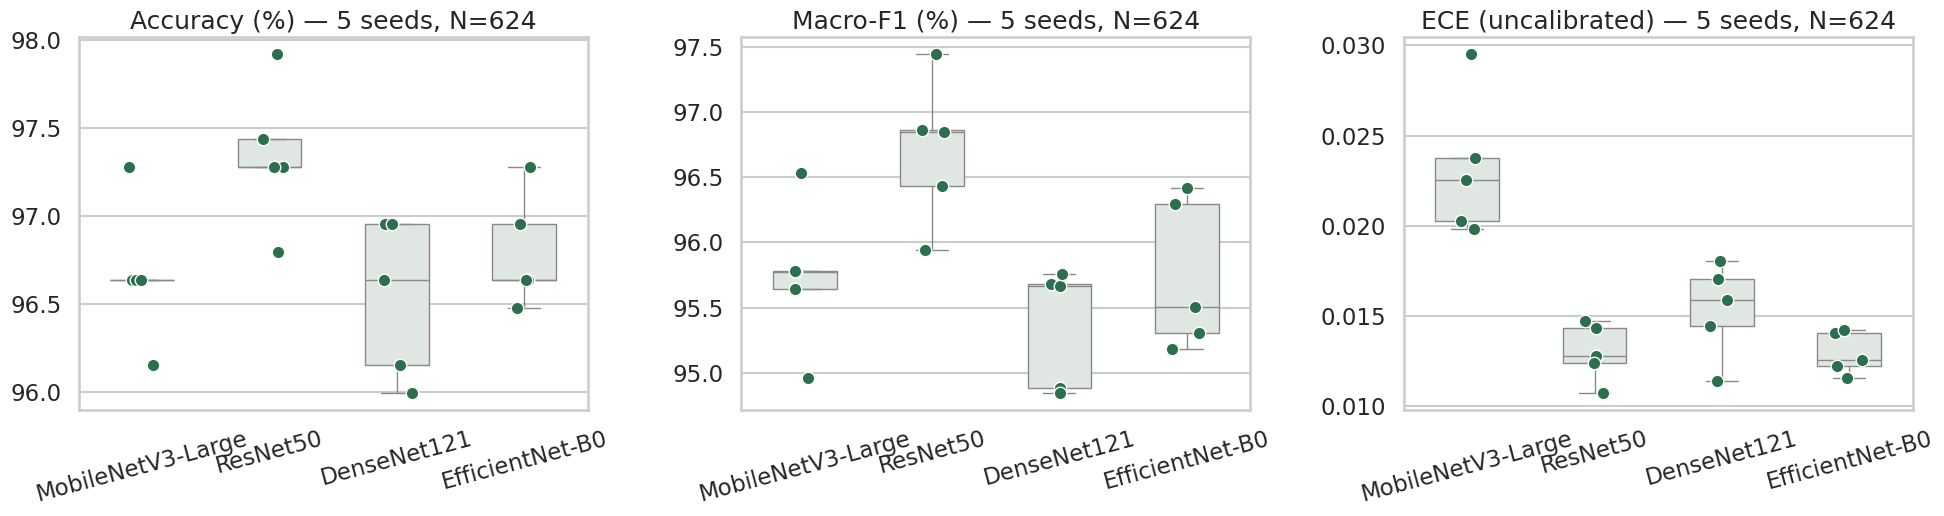

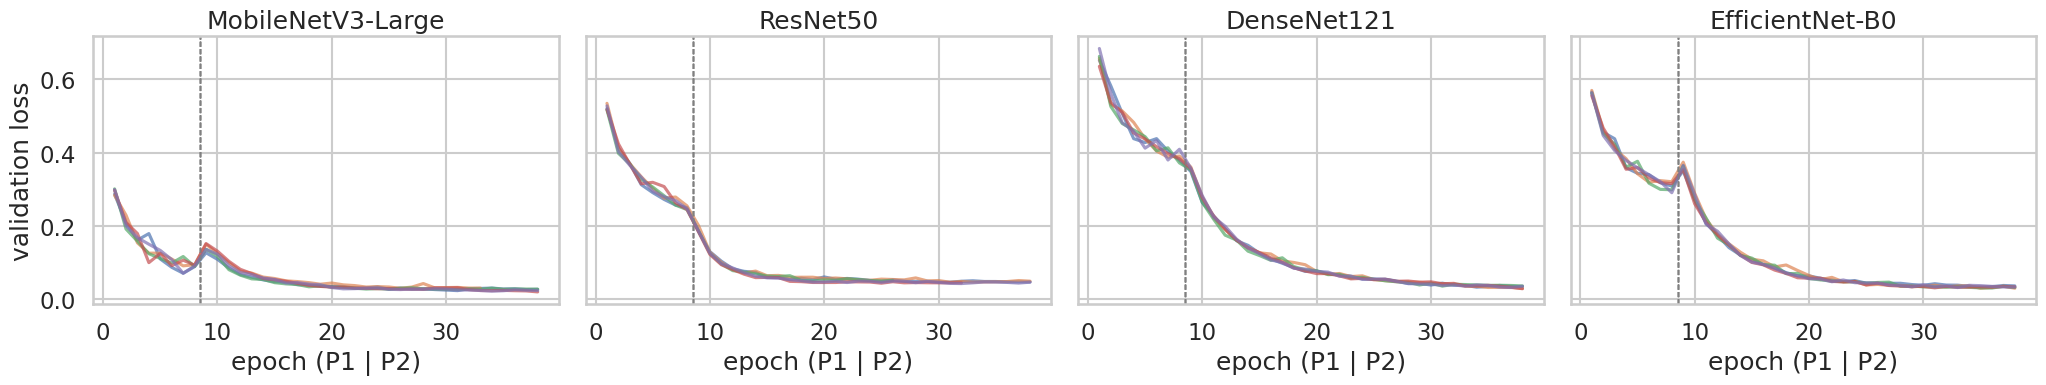

In [12]:
# ============================================================
# 12 — FIGURES
# ============================================================
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
plot_res = res.assign(Model=res["model"].map(DISPLAY), acc=res["test_acc"] * 100, f1=res["test_macro_f1"] * 100)
xorder = [DISPLAY[m] for m in order]
for ax, (col, title) in zip(axes, [("acc", "Accuracy (%)"), ("f1", "Macro-F1 (%)"), ("test_ece", "ECE (uncalibrated)")]):
    sns.boxplot(data=plot_res, x="Model", y=col, order=xorder, ax=ax, width=0.5, showfliers=False, color="#dfe8e2")
    sns.stripplot(data=plot_res, x="Model", y=col, order=xorder, ax=ax, size=9, color="#2b6f4f", jitter=0.12, edgecolor="white", linewidth=1)
    ax.set_title(f"{title} — {plot_res.seed.nunique()} seeds, N=624"); ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.savefig(OUT_DIR / "FIG_multiseed_boxplots.png", dpi=200, bbox_inches="tight"); plt.show()

# training curves (mean over seeds, val loss; dashed line = start of phase 2)
fig, axes = plt.subplots(1, len(order), figsize=(5.2 * len(order), 4.2), sharey=True)
axes = np.atleast_1d(axes)
for ax, m in zip(axes, order):
    for f in sorted(RUNS_DIR.glob(f"{m}_seed*_history.csv")):
        h = pd.read_csv(f); h["x"] = np.arange(1, len(h) + 1)
        ax.plot(h["x"], h["val_loss"], alpha=0.7)
        ax.axvline(P1_EPOCHS + 0.5, ls="--", c="gray", lw=1)
    ax.set_title(DISPLAY[m]); ax.set_xlabel("epoch (P1 | P2)")
axes[0].set_ylabel("validation loss")
plt.tight_layout(); plt.savefig(OUT_DIR / "FIG_val_loss_curves_all_seeds.png", dpi=200, bbox_inches="tight"); plt.show()

In [13]:
# ============================================================
# 13 — PACKAGE OUTPUTS
# ============================================================
zip_path = shutil.make_archive("/kaggle/working/two_phase_multiseed_results", "zip", OUT_DIR)
print("✓", zip_path, f"({Path(zip_path).stat().st_size/1e6:.1f} MB)")
print("Per-run logits are in runs/*_preds.npz  ->  reuse them for McNemar tests, seed-matched cascade simulation, calibration plots.")

✓ /kaggle/working/two_phase_multiseed_results.zip (1.2 MB)
Per-run logits are in runs/*_preds.npz  ->  reuse them for McNemar tests, seed-matched cascade simulation, calibration plots.
